# Tier 1 (Person C): CNN on **MFCC + Δ + ΔΔ** for Slavic Language Identification

## What this notebook does
- Loads the same preprocessed 3-second audio chunks from HuggingFace as Person A
- Extracts **40 MFCCs + delta + delta-delta = 120-dim** features (instead of A's 80 log-Mel bins)
- Applies the **same** SpecAugment during training
- Trains the **same** small CNN classifier (byte-for-byte A's architecture)
- Evaluates per-language accuracy, macro-F1, confusion matrix, and t-SNE
- Reports on the shared **test** split and the held-out **eval_fleurs** split
- Saves all metrics to `results.json` (team convention)

## Research question for this tier
**Mel vs MFCC** — C Tier 1 vs A Tier 1. The *only* thing that changes versus A is the
input representation. Everything else (front-end FFT settings, SpecAugment params, model,
optimizer, schedule, seed, splits, epochs) is identical, so any accuracy difference is
attributable to Mel-vs-MFCC alone.

## Team conventions followed
- Same HuggingFace dataset, same **train / test / eval_fleurs** splits
- Seed = **42**, Tier 1 = **30 epochs**
- Metrics: per-language accuracy, macro-F1, confusion matrix → saved to **`results.json`**

## Languages
Belarussian, Bulgarian, Czech, Macedonian, Polish, Russian, Serbian, Ukranian


In [1]:
!pip install -q datasets torchaudio librosa scikit-learn matplotlib seaborn torch

In [2]:
import os
import json
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchaudio
import torchaudio.transforms as T
from datasets import load_dataset, Audio
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [3]:
from huggingface_hub import login
from google.colab import userdata

login(token=userdata.get("HF_TOKEN"))

In [4]:
REPO_ID = "su-fmi-pytorch-slavic/slavic-languages-dataset"

In [5]:
from google.colab import drive
drive.mount('/content/drive')
assert os.path.exists("/content/drive/MyDrive"), "Drive not mounted!"

# NOTE: separate cache + checkpoint folders from A so we never collide on the shared Drive.
# We cache ONLY the 40 static MFCCs (40 x 300). Deltas are recomputed on the fly in the
# Dataset, which keeps RAM ~3x smaller than storing the full 120-dim tensor -> fits free Colab.
CACHE_DIR        = "/content/drive/MyDrive/slavic_lid"
CKPT_DIR         = f"{CACHE_DIR}/tier1_mfcc"
CACHE_NPZ_TRAIN  = f"{CACHE_DIR}/train_mfcc_f16.npz"
CACHE_NPZ_TEST   = f"{CACHE_DIR}/test_mfcc_f16.npz"
CACHE_NPZ_FLEURS = f"{CACHE_DIR}/fleurs_mfcc_f16.npz"   # team-convention eval split
os.makedirs(CKPT_DIR, exist_ok=True)


def _load_npz(path):
    d = np.load(path)
    return d["X"], d["y"]


if os.path.exists(CACHE_NPZ_TRAIN) and os.path.exists(CACHE_NPZ_TEST):
    print("MFCC cache found on Drive — loading (skipping HuggingFace download)...")
    X_train, y_train = _load_npz(CACHE_NPZ_TRAIN)
    X_test,  y_test  = _load_npz(CACHE_NPZ_TEST)
    if os.path.exists(CACHE_NPZ_FLEURS):
        X_fleurs, y_fleurs = _load_npz(CACHE_NPZ_FLEURS)
        print(f"  FLEURS eval cache found: {X_fleurs.shape}")
    else:
        X_fleurs = y_fleurs = None
        print("  No FLEURS eval cache (will be skipped).")
    raw = None
    print(f"  Train: {X_train.shape}  ({X_train.nbytes / 1e9:.2f} GB in RAM)")
    print(f"  Test:  {X_test.shape}  ({X_test.nbytes / 1e9:.2f} GB in RAM)")
    print("Ready — skip to the 'Dataset classes' cell.")
else:
    print("No MFCC cache found. Downloading raw dataset from HuggingFace...")
    print("(This only happens once. Results are saved to Drive for all future restarts.)")
    raw = load_dataset(REPO_ID)
    X_train = y_train = X_test = y_test = X_fleurs = y_fleurs = None
    print(raw)

Mounted at /content/drive
MFCC cache found on Drive — loading (skipping HuggingFace download)...
  No FLEURS eval cache (will be skipped).
  Train: (80000, 12000)  (1.92 GB in RAM)
  Test:  (107439, 12000)  (2.58 GB in RAM)
Ready — skip to the 'Dataset classes' cell.


In [6]:
# Verify Drive is mounted before processing
assert os.path.exists("/content/drive/MyDrive"), "Drive not mounted!"
print("Drive confirmed mounted")

Drive confirmed mounted


In [7]:
if raw is not None:
    sample = raw["train"][0]
    print("Splits available:", list(raw.keys()))
    print("Keys:", list(sample.keys()))
    print("Language:", sample["language"])
    print("Label:", sample["label"])
    print("Source:", sample["source"])
    print("Audio array shape:", np.array(sample["audio"]["array"]).shape)
    print("Audio sampling rate:", sample["audio"]["sampling_rate"])
else:
    print("Skipping sample inspection — using pre-cached MFCCs from Drive.")

Skipping sample inspection — using pre-cached MFCCs from Drive.


## Feature Extraction: MFCC + Δ + ΔΔ

This is the **only** real difference from Person A. A feeds 80 log-Mel bins straight into
the CNN; we take the same mel front-end, apply the DCT to get **40 MFCCs**, then add the
first derivative (**delta**) and second derivative (**delta-delta**) → a **120 × 300** image.

Key choices that keep the comparison fair:
- **Same front-end as A**: `n_fft=400`, `hop_length=160`, `n_mels=80`, `f_min=20`, `f_max=8000`.
  Identical FFT/hop means the time axis (300 frames) is identical to A — only the
  frequency→cepstral transform differs.
- **Normalization**: per-coefficient (CMVN-style) instance normalization. Each of the 120 rows
  is normalized to zero-mean/unit-var over time. This is the standard, *fair* treatment for
  MFCCs — their coefficients (energy c0, higher cepstra, statics vs deltas) live on wildly
  different scales, so A's single global per-sample norm would unfairly let c0 dominate.
  This is the one principled exception to "identical preprocessing"; it gives MFCC its
  correct canonical normalization, just as A's global norm is correct for log-Mel.
- **SpecAugment is kept identical** (F=15 ×2, T=40 ×2). On MFCCs the frequency mask masks
  *cepstral coefficients* — slightly unusual but kept identical to A on purpose so SpecAugment
  is not a confound.

**Colab optimization:** we cache only the **40 static MFCCs** to Drive and recompute the
two delta streams on the fly in the Dataset. Storing 40×300 instead of 120×300 cuts the
cached arrays to ~1/3 (~4.5 GB total vs ~13.5 GB), which is what makes this fit in free
Colab RAM. ComputeDeltas is a tiny 1-D conv, so the on-the-fly cost is negligible and is
hidden behind the dataloader workers.


In [8]:
SAMPLE_RATE = 16_000
N_FFT = 400
HOP_LENGTH = 160
N_MELS = 80            # mel filterbank feeding the MFCC (same resolution as A)
N_MFCC = 40            # cepstral coefficients kept
N_FEAT = N_MFCC * 3    # 40 static + 40 delta + 40 delta-delta = 120
TARGET_LENGTH = 300
FREQ_MASK_F = 15
TIME_MASK_T = 40

LANGUAGES = ["be", "bg", "cs", "mk", "pl", "ru", "sr", "uk"]
LANG2ID = {lang: i for i, lang in enumerate(sorted(LANGUAGES))}
ID2LANG = {v: k for k, v in LANG2ID.items()}

# MFCC front-end: same mel settings as A's MelSpectrogram, then DCT -> 40 coeffs.
mfcc_transform = T.MFCC(
    sample_rate=SAMPLE_RATE,
    n_mfcc=N_MFCC,
    melkwargs=dict(
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        f_min=20,
        f_max=8000,
    ),
)

# delta / delta-delta operator (5-tap regression filter, the standard default)
compute_deltas = T.ComputeDeltas()


def waveform_to_mfcc(waveform: torch.Tensor) -> torch.Tensor:
    """Raw 40-dim static MFCC, padded/cropped to TARGET_LENGTH. No normalization here —
    normalization happens after we add deltas (see build_feature)."""
    mfcc = mfcc_transform(waveform.unsqueeze(0)).squeeze(0)   # (N_MFCC, T)
    cur_len = mfcc.shape[-1]
    if cur_len < TARGET_LENGTH:
        mfcc = F.pad(mfcc, (0, TARGET_LENGTH - cur_len))
    else:
        mfcc = mfcc[..., :TARGET_LENGTH]
    return mfcc                                               # (40, 300)


def build_feature(mfcc: torch.Tensor) -> torch.Tensor:
    """40 static MFCC -> 120-dim (static|delta|delta-delta), per-coefficient normalized.
    Returns a single-channel (1, 120, 300) tensor ready for the CNN."""
    d1 = compute_deltas(mfcc)
    d2 = compute_deltas(d1)
    feat = torch.cat([mfcc, d1, d2], dim=0)                   # (120, 300)
    mean = feat.mean(dim=-1, keepdim=True)                    # per-coefficient (CMVN-style)
    std = feat.std(dim=-1, keepdim=True) + 1e-6
    feat = (feat - mean) / std
    return feat.unsqueeze(0)                                  # (1, 120, 300)


# SpecAugment — IDENTICAL params to A (kept fixed so it is not a confound).
specaugment_train = nn.Sequential(
    T.FrequencyMasking(freq_mask_param=FREQ_MASK_F),
    T.FrequencyMasking(freq_mask_param=FREQ_MASK_F),
    T.TimeMasking(time_mask_param=TIME_MASK_T),
    T.TimeMasking(time_mask_param=TIME_MASK_T),
)

In [9]:
# ── Extract STATIC MFCCs and save to Drive (only runs when no cache exists) ───
# On the FIRST run this takes a few minutes and saves ~4.5 GB to your Drive.
# Every restart after that jumps straight to "MFCC cache found" in the cell above.

if raw is not None:
    def _extract_mfcc(split, desc):
        n = len(split)
        X = np.empty((n, N_MFCC * TARGET_LENGTH), dtype=np.float16)   # 40*300 only
        y = np.empty(n, dtype=np.int32)
        for i, ex in enumerate(tqdm(split, desc=desc, total=n)):
            wav = torch.tensor(ex["audio"]["array"], dtype=torch.float32)
            mfcc = waveform_to_mfcc(wav)
            X[i] = mfcc.numpy().flatten().astype(np.float16)
            y[i] = int(ex["label"])
        return X, y

    print("Extracting train MFCCs (runs once, saved to Drive)...")
    X_train, y_train = _extract_mfcc(raw["train"], "Train")
    np.savez_compressed(CACHE_NPZ_TRAIN, X=X_train, y=y_train)
    print(f"  Saved {os.path.getsize(CACHE_NPZ_TRAIN) / 1e9:.2f} GB to {CACHE_NPZ_TRAIN}")

    print("Extracting test MFCCs...")
    X_test, y_test = _extract_mfcc(raw["test"], "Test")
    np.savez_compressed(CACHE_NPZ_TEST, X=X_test, y=y_test)
    print(f"  Saved {os.path.getsize(CACHE_NPZ_TEST) / 1e9:.2f} GB to {CACHE_NPZ_TEST}")

    # eval_fleurs: shared team-convention split (cross-domain generalization check).
    # Detect the split name robustly; skip cleanly if the dataset does not ship it.
    fleurs_split = next((s for s in raw.keys() if "fleurs" in s.lower()), None)
    if fleurs_split is not None:
        print(f"Extracting eval MFCCs from split '{fleurs_split}'...")
        X_fleurs, y_fleurs = _extract_mfcc(raw[fleurs_split], "FLEURS")
        np.savez_compressed(CACHE_NPZ_FLEURS, X=X_fleurs, y=y_fleurs)
        print(f"  Saved {os.path.getsize(CACHE_NPZ_FLEURS) / 1e9:.2f} GB to {CACHE_NPZ_FLEURS}")
    else:
        X_fleurs = y_fleurs = None
        print("No 'eval_fleurs'-like split found in dataset — skipping FLEURS eval.")

    del raw
    import gc; gc.collect()
    print("\nDone! Future restarts load from Drive in seconds (no re-download needed).")
else:
    print("Cache already loaded — nothing to do here.")

_fleurs_n = "(none)" if y_fleurs is None else f"{len(y_fleurs):,}"
print(f"\nTrain: {len(y_train):,} | Test: {len(y_test):,} | FLEURS: {_fleurs_n}")

Cache already loaded — nothing to do here.

Train: 80,000 | Test: 107,439 | FLEURS: (none)


In [10]:
class SlavicLIDDataset(Dataset):
    """Reads pre-extracted 40-dim static MFCCs, expands to 120-dim (static|delta|delta-delta),
    per-coefficient normalizes, and optionally applies SpecAugment."""
    def __init__(self, X: np.ndarray, y: np.ndarray, augment: bool = False):
        self.X = X          # shape (N, N_MFCC * TARGET_LENGTH), dtype float16
        self.y = y          # shape (N,), dtype int32
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        mfcc = torch.from_numpy(self.X[idx].astype(np.float32)).reshape(N_MFCC, TARGET_LENGTH)
        feat = build_feature(mfcc)            # (1, 120, 300), normalized
        if self.augment:
            feat = specaugment_train(feat)
        return feat, int(self.y[idx])

In [11]:
ds_tmp = SlavicLIDDataset(X_train, y_train, augment=False)
spec_clean, label = ds_tmp[42]

ds_aug = SlavicLIDDataset(X_train, y_train, augment=True)
spec_aug, _ = ds_aug[42]

Visualize a sample feature map (120 rows = 40 MFCC | 40 Δ | 40 ΔΔ)

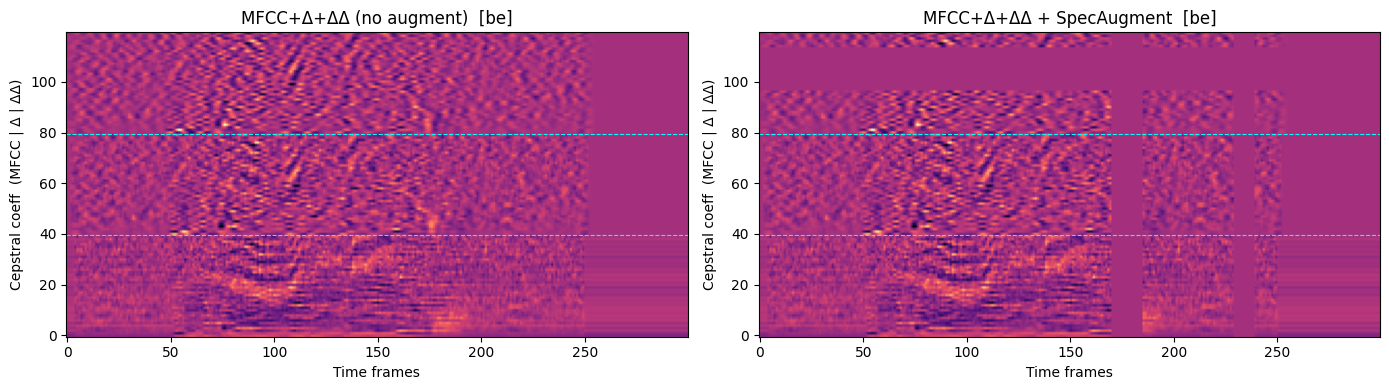

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, spec, title in zip(axes,
                            [spec_clean, spec_aug],
                            ["MFCC+Δ+ΔΔ (no augment)", "MFCC+Δ+ΔΔ + SpecAugment"]):
    ax.imshow(spec.squeeze().numpy(), origin="lower", aspect="auto", cmap="magma")
    ax.axhline(N_MFCC - 0.5, color="cyan", lw=0.8, ls="--")     # static | delta boundary
    ax.axhline(2 * N_MFCC - 0.5, color="cyan", lw=0.8, ls="--") # delta | delta-delta boundary
    ax.set_xlabel("Time frames")
    ax.set_ylabel("Cepstral coeff  (MFCC | Δ | ΔΔ)")
    ax.set_title(f"{title}  [{ID2LANG[label]}]")

plt.tight_layout()
plt.show()

Dataloaders

In [13]:
BATCH_SIZE = 32

# Small random subset of the test set used for fast per-epoch validation (same seed/size as A)
rng = np.random.default_rng(42)
small_idx = rng.choice(len(y_test), size=min(16_000, len(y_test)), replace=False)

train_dataset      = SlavicLIDDataset(X_train,           y_train,           augment=True)
test_small_dataset = SlavicLIDDataset(X_test[small_idx], y_test[small_idx], augment=False)
test_full_dataset  = SlavicLIDDataset(X_test,            y_test,            augment=False)

# num_workers=2 + persistent_workers hides the on-the-fly delta/normalization cost behind
# the GPU. This is a speed-only change; it does not affect the Mel-vs-MFCC comparison.
train_loader      = DataLoader(train_dataset,      batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True, persistent_workers=True)
test_small_loader = DataLoader(test_small_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)
test_full_loader  = DataLoader(test_full_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)

# eval_fleurs loader (only if the split was found / cached)
if X_fleurs is not None:
    fleurs_dataset = SlavicLIDDataset(X_fleurs, y_fleurs, augment=False)
    fleurs_loader  = DataLoader(fleurs_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)
else:
    fleurs_dataset = fleurs_loader = None

print(f"Train:      {len(train_dataset):,} samples")
print(f"Test small: {len(test_small_dataset):,} samples  (used during training)")
print(f"Test full:  {len(test_full_dataset):,} samples  (used for final eval)")
print(f"FLEURS:     {len(fleurs_dataset):,} samples  (cross-domain eval)" if fleurs_loader else "FLEURS:     (none)")

Train:      80,000 samples
Test small: 16,000 samples  (used during training)
Test full:  107,439 samples  (used for final eval)
FLEURS:     (none)


## Model Architecture

This is **byte-for-byte Person A's CNN**. Because the last conv stage ends in
`AdaptiveAvgPool2d((1,1))`, the network is agnostic to the input height — it accepts our
`(1, 120, 300)` MFCC stack with **no code change at all** (A fed `(1, 80, 300)`). Keeping
the model identical is exactly what isolates the feature representation as the only variable.


In [14]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

In [15]:
class MelCNN(nn.Module):
    """Identical architecture to Person A. Name kept for 1:1 comparability.
    AdaptiveAvgPool2d makes it accept 120-row MFCC input unchanged."""
    def __init__(self, n_classes: int = 8):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(1, 32), nn.MaxPool2d(2, 2),
            ConvBlock(32, 64), nn.MaxPool2d(2, 2),
            ConvBlock(64, 128), nn.MaxPool2d(2, 2),
            ConvBlock(128, 256), nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.embed = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
        )
        self.classifier = nn.Linear(128, n_classes)

    def forward(self, x):
        h = self.features(x)
        e = self.embed(h)
        return self.classifier(e)

    def get_embeddings(self, x):
        h = self.features(x)
        return self.embed(h)

In [16]:
model = MelCNN(n_classes=8).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

dummy = torch.zeros(4, 1, N_FEAT, TARGET_LENGTH).to(DEVICE)   # (4, 1, 120, 300)
print(f"Output shape: {model(dummy).shape}")
print(f"Embedding shape: {model.get_embeddings(dummy).shape}")

Trainable parameters: 422,248
Output shape: torch.Size([4, 8])
Embedding shape: torch.Size([4, 128])


Training setup (identical hyperparameters to A; Tier 1 = 30 epochs per team conventions)

In [17]:
EPOCHS = 30          # team convention: Tier 1 = 30 epochs (same as A)
LR = 1e-3
WD = 1e-4

criterion = nn.CrossEntropyLoss(label_smoothing=0.0)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [18]:
def run_epoch(model, loader, criterion, optimizer, train: bool):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for specs, labels in tqdm(loader, leave=False):
            specs, labels = specs.to(DEVICE), labels.to(DEVICE)

            logits = model(specs)
            loss = criterion(logits, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * labels.size(0)
            correct += (logits.argmax(1) == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total

In [19]:
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

In [20]:
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, train=True)
    te_loss, te_acc = run_epoch(model, test_small_loader, criterion, optimizer, train=False)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["test_loss"].append(te_loss)
    history["test_acc"].append(te_acc)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | "
              f"Train loss {tr_loss:.4f} acc {tr_acc:.3f} | "
              f"Test  loss {te_loss:.4f} acc {te_acc:.3f}")

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch   1/30 | Train loss 1.6058 acc 0.385 | Test  loss 3.7195 acc 0.109


  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

...

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch  30/30 | Train loss 0.3921 acc 0.858 | Test  loss 2.4762 acc 0.424


Save a checkpoint to Drive

In [21]:
# CKPT_DIR (tier1_mfcc) is already defined in the Drive-setup cell above.
torch.save({
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "history": history,
    "hparams": {"features": "mfcc+d+dd", "n_mfcc": N_MFCC, "n_feat": N_FEAT,
                "epochs": EPOCHS, "lr": LR, "batch": BATCH_SIZE},
}, f"{CKPT_DIR}/mfcc_cnn_final.pt")

print(f"Checkpoint saved to {CKPT_DIR}/mfcc_cnn_final.pt")

Checkpoint saved to /content/drive/MyDrive/slavic_lid/tier1_mfcc/mfcc_cnn_final.pt


Learning curves

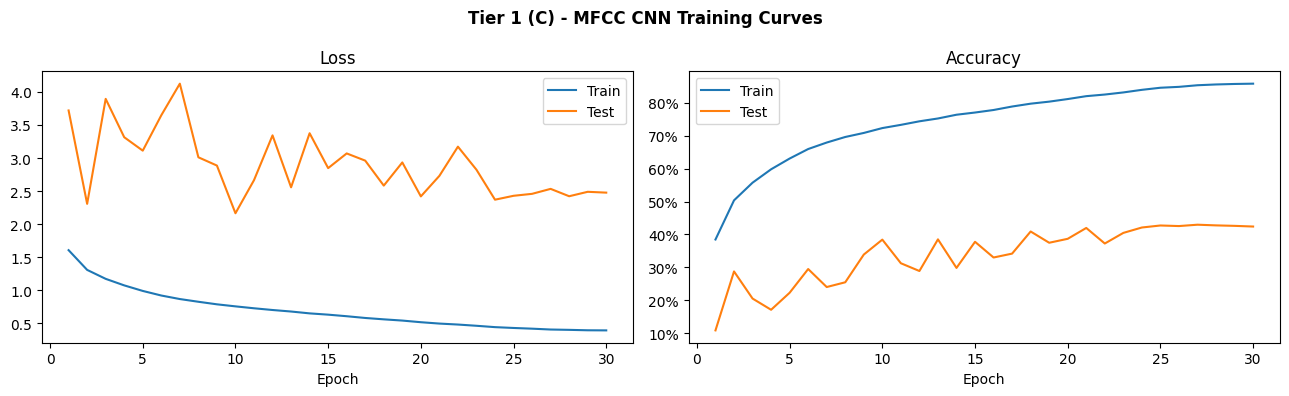

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

epochs = range(1, EPOCHS + 1)
ax1.plot(epochs, history["train_loss"], label="Train")
ax1.plot(epochs, history["test_loss"],  label="Test")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend()

ax2.plot(epochs, history["train_acc"], label="Train")
ax2.plot(epochs, history["test_acc"],  label="Test")
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.suptitle("Tier 1 (C) - MFCC CNN Training Curves", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/learning_curves.png", dpi=150)
plt.show()

## Evaluation (test split)

In [23]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for specs, labels in tqdm(test_full_loader, desc="Evaluating"):
        specs  = specs.to(DEVICE)
        preds  = model(specs).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# overall
overall_acc = (all_preds == all_labels).mean()
macro_f1 = f1_score(all_labels, all_preds, average="macro")
print(f"\nOverall Accuracy: {overall_acc:.4f} ({overall_acc*100:.2f}%)")
print(f"Macro-F1 : {macro_f1:.4f}")
print()

# per-language
print(classification_report(all_labels, all_preds, target_names=LANGUAGES, digits=3))

Evaluating:   0%|          | 0/3358 [00:00<?, ?it/s]


Overall Accuracy: 0.4266 (42.66%)
Macro-F1 : 0.3105

              precision    recall  f1-score   support

          be      0.538     0.698     0.608     29232
          bg      0.345     0.078     0.127      6318
          cs      0.476     0.319     0.382     14441
          mk      0.224     0.158     0.185      3263
          pl      0.464     0.386     0.421     16949
          ru      0.331     0.526     0.406     19069
          sr      0.111     0.137     0.123      1666
          uk      0.313     0.184     0.232     16501

    accuracy                          0.427    107439
   macro avg      0.350     0.311     0.310    107439
weighted avg      0.419     0.427     0.406    107439



Confusion matrix

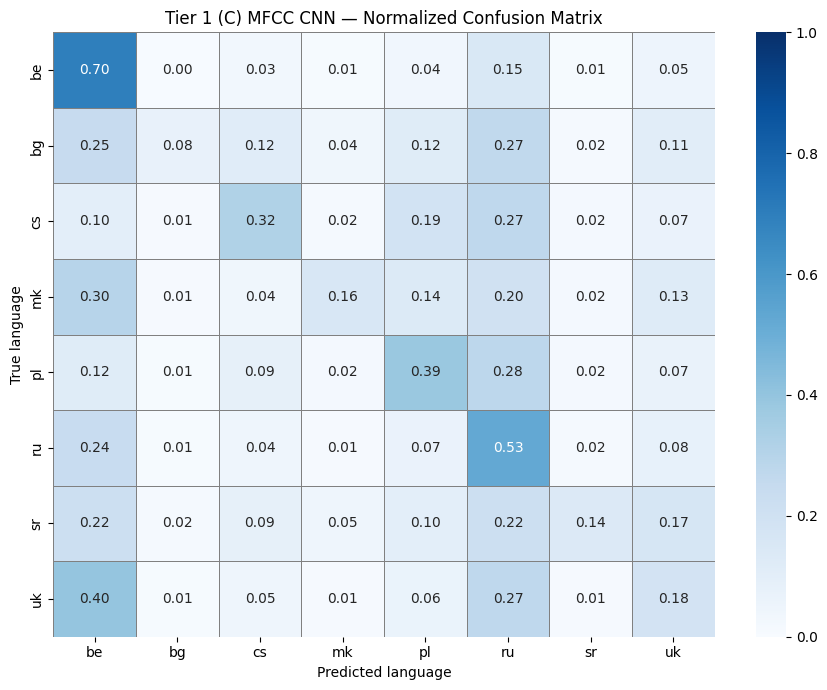

In [24]:
cm = confusion_matrix(all_labels, all_preds, normalize="true")

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=LANGUAGES, yticklabels=LANGUAGES, ax=ax,
            linewidths=0.5, linecolor="gray", vmin=0, vmax=1)

ax.set_xlabel("Predicted language")
ax.set_ylabel("True language")
ax.set_title("Tier 1 (C) MFCC CNN — Normalized Confusion Matrix")

plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/confusion_matrix.png", dpi=150)
plt.show()

## Cross-domain evaluation (eval_fleurs split)

Same model, same metrics, evaluated on the held-out FLEURS split (team convention).
Runs only if the dataset shipped an `eval_fleurs`-like split.

In [25]:
if fleurs_loader is not None:
    model.eval()
    fl_preds, fl_labels = [], []
    with torch.no_grad():
        for specs, labels in tqdm(fleurs_loader, desc="Evaluating (FLEURS)"):
            preds = model(specs.to(DEVICE)).argmax(1).cpu()
            fl_preds.extend(preds.tolist())
            fl_labels.extend(labels.tolist())

    fl_preds, fl_labels = np.array(fl_preds), np.array(fl_labels)
    fleurs_acc = float((fl_preds == fl_labels).mean())
    fleurs_macro_f1 = float(f1_score(fl_labels, fl_preds, average="macro"))
    fleurs_report = classification_report(fl_labels, fl_preds, target_names=LANGUAGES,
                                          output_dict=True, digits=4, zero_division=0)
    fleurs_cm = confusion_matrix(fl_labels, fl_preds, normalize="true")

    print(f"FLEURS Accuracy : {fleurs_acc:.4f} ({fleurs_acc*100:.2f}%)")
    print(f"FLEURS Macro-F1 : {fleurs_macro_f1:.4f}")
    print()
    print(classification_report(fl_labels, fl_preds, target_names=LANGUAGES, digits=3, zero_division=0))
else:
    fleurs_acc = fleurs_macro_f1 = None
    fleurs_report = fleurs_cm = None
    print("No FLEURS split available — skipping cross-domain eval.")

No FLEURS split available — skipping cross-domain eval.


## Save `results.json` (team convention)

All Tier-1 metrics in one file so the four people's results stay directly comparable.

In [26]:
# Per-language metrics from the test split
test_report = classification_report(all_labels, all_preds, target_names=LANGUAGES,
                                    output_dict=True, digits=4, zero_division=0)
cm_counts = confusion_matrix(all_labels, all_preds)
cm_norm   = confusion_matrix(all_labels, all_preds, normalize="true")
per_lang_acc = {lang: float(cm_norm[i, i]) for i, lang in enumerate(LANGUAGES)}

results = {
    "tier": 1,
    "person": "C",
    "representation": "mfcc+delta+delta-delta (40x3=120-dim)",
    "research_question": "Mel (A) vs MFCC (C) for Slavic LID",
    "seed": SEED,
    "epochs": EPOCHS,
    "languages": LANGUAGES,
    "test": {
        "overall_accuracy": float(overall_acc),
        "macro_f1": float(macro_f1),
        "per_language_accuracy": per_lang_acc,
        "classification_report": test_report,
        "confusion_matrix": cm_counts.tolist(),
        "confusion_matrix_normalized": cm_norm.tolist(),
    },
    "eval_fleurs": (
        {
            "overall_accuracy": fleurs_acc,
            "macro_f1": fleurs_macro_f1,
            "classification_report": fleurs_report,
            "confusion_matrix_normalized": (fleurs_cm.tolist() if fleurs_cm is not None else None),
        }
        if fleurs_acc is not None else None
    ),
    "history": history,
}

results_path = f"{CKPT_DIR}/results.json"
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)
print(f"Saved metrics to {results_path}")
print(f"  test acc = {overall_acc*100:.2f}% | macro-F1 = {macro_f1:.4f}"
      + (f" | FLEURS acc = {fleurs_acc*100:.2f}%" if fleurs_acc is not None else ""))

Saved metrics to /content/drive/MyDrive/slavic_lid/tier1_mfcc/results.json
  test acc = 42.66% | macro-F1 = 0.3105


## t-SNE of learned embeddings

Per-language test counts: {'be': 29232, 'bg': 6318, 'cs': 14441, 'mk': 3263, 'pl': 16949, 'ru': 19069, 'sr': 1666, 'uk': 16501}
PER_LANG = 1666 (smallest language) -> 13328 points total


Extracting embeddings:   0%|          | 0/417 [00:00<?, ?it/s]

Fitting t-SNE on 13328 points (perplexity=40)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


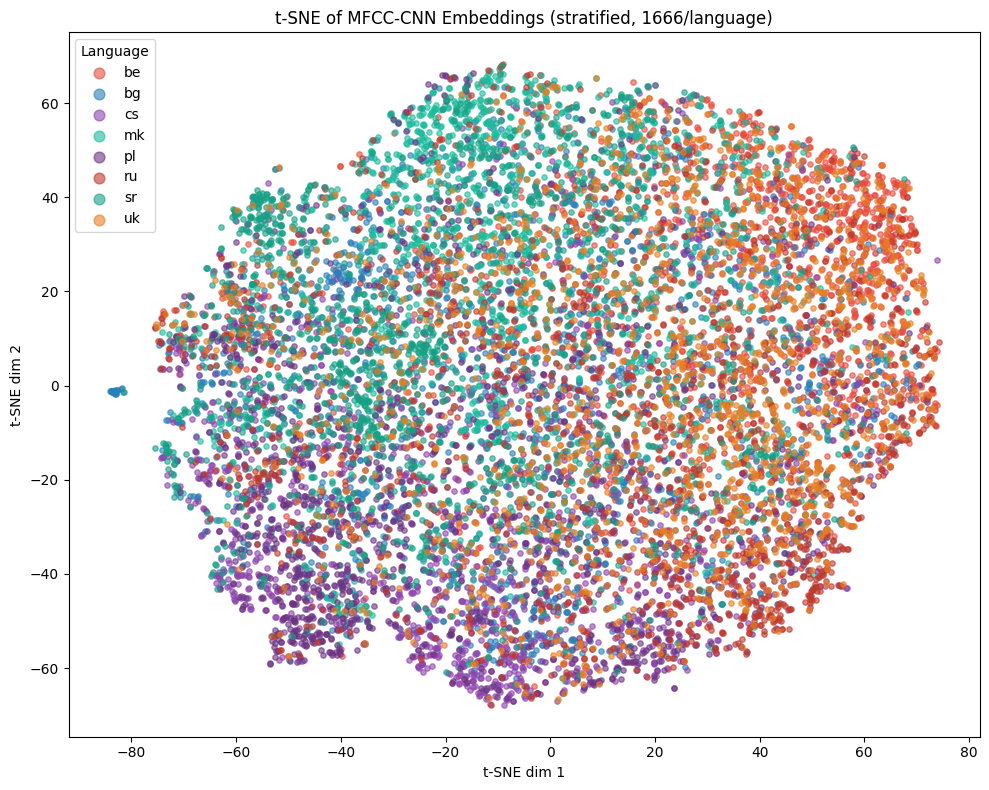

In [27]:
# Stratified sampling: equal number of clips per language so the plot is balanced and
# the A-vs-C comparison is fair. PER_LANG = size of the SMALLEST language in the test set,
# which guarantees strict balance with no class taken with replacement.
counts = np.bincount(y_test, minlength=len(LANGUAGES))
PER_LANG = int(counts.min())
print(f"Per-language test counts: {dict(zip(LANGUAGES, counts.tolist()))}")
print(f"PER_LANG = {PER_LANG} (smallest language) -> {PER_LANG * len(LANGUAGES)} points total")

rng = np.random.default_rng(SEED)
tsne_idx = np.concatenate([
    rng.choice(np.where(y_test == lang_id)[0], size=PER_LANG, replace=False)
    for lang_id in range(len(LANGUAGES))
])

tsne_dataset = SlavicLIDDataset(X_test[tsne_idx], y_test[tsne_idx], augment=False)
tsne_loader  = DataLoader(tsne_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

model.eval()
embeddings, labels_tsne = [], []
with torch.no_grad():
    for specs, lbls in tqdm(tsne_loader, desc="Extracting embeddings"):
        emb = model.get_embeddings(specs.to(DEVICE)).cpu().numpy()
        embeddings.append(emb)
        labels_tsne.extend(lbls.tolist())

embeddings = np.concatenate(embeddings, axis=0)
labels_tsne = np.array(labels_tsne)

# fit t-SNE (perplexity guarded in case the smallest language is tiny)
perp = min(40, max(5, (len(embeddings) - 1) // 3))
print(f"Fitting t-SNE on {len(embeddings)} points (perplexity={perp})...")
tsne = TSNE(n_components=2, perplexity=perp, random_state=SEED, n_iter=1000)
proj = tsne.fit_transform(embeddings)

# Plot
BRANCH_COLORS = {
    "be": "#e74c3c",  # East Slavic - red family
    "ru": "#c0392b",
    "uk": "#e67e22",
    "bg": "#2980b9",  # South Slavic - blue family
    "mk": "#1abc9c",
    "sr": "#16a085",
    "cs": "#8e44ad",  # West Slavic - purple family
    "pl": "#6c3483",
}

fig, ax = plt.subplots(figsize=(10, 8))
for lang_id, lang in ID2LANG.items():
    mask = labels_tsne == lang_id
    ax.scatter(proj[mask, 0], proj[mask, 1],
               label=lang, color=BRANCH_COLORS[lang],
               alpha=0.6, s=15)

ax.legend(title="Language", fontsize=10, markerscale=2)
ax.set_title(f"t-SNE of MFCC-CNN Embeddings (stratified, {PER_LANG}/language)")
ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/tsne.png", dpi=150)
plt.show()

## Tier 1 (C) Results & Conclusions

### 0. Headline comparison — Mel vs MFCC  ← this is C's research question
Fill in side by side with A's numbers (same test set, same model, same seed, same 30 epochs):

| Representation | Test acc | Macro-F1 | FLEURS acc |
|---|---|---|---|
| A — 80 log-Mel | XX.X% | 0.XXX | XX.X% |
| C — 40 MFCC + Δ + ΔΔ | XX.X% | 0.XXX | XX.X% |

- Which wins, and by how much?
- Expectation: for CNNs, log-Mel usually matches or slightly beats MFCC, because the CNN can
  learn its own decorrelation and the DCT in MFCC discards information. A small Mel-favoring
  gap is a perfectly good, reportable finding (and a clean motivation for the rest of the project).

### 1. Overall performance
- **Test accuracy**: XX.X%   |   **Macro-F1**: 0.XXX
- Random baseline (8-class uniform): 12.5%

### 2. Per-language analysis (from classification_report)
- Best / worst recognized language and why.
- Do the *same* languages that A struggles with also struggle here? (If yes → feature-agnostic
  difficulty, likely the languages are genuinely close. If no → the representation matters.)

### 3. Confusion matrix observations
- Highest off-diagonal cell.
- Do confusions follow Slavic branch structure (South bg/mk/sr, East ru/uk/be, West cs/pl)?
- Are MFCC confusions *more* or *less* branch-structured than A's Mel confusions?

### 4. t-SNE embedding analysis
- Are language clusters visible? Do East/West/South branches form macro-clusters?
- Visually tighter or looser than A's Mel embeddings? (Compare using the **same** stratified
  sampling scheme + seed as A so the comparison is fair, not a plotting artifact.)

### 5. Cross-domain check — eval_fleurs
- Gap between in-domain **test** and out-of-domain **FLEURS** accuracy.
- Does MFCC generalize to FLEURS better or worse than A's Mel? A larger drop = more domain-sensitive.

### 6. Hand-off to Tier 2
- Note that Tier 2 switches **back to Mel** (to match A) and the new variable becomes **Mixup**.
  MFCC lives only in this tier.

_All numbers above are written to `results.json` in the checkpoint folder for the shared report._
